In [1]:
import math
import random
from collections import deque

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42

def set_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(SEED)

In [2]:
# State = [time_fraction, time_to_expiry, moneyness]  -> matches Q-network state_dim=3
# time_fraction   = step / steps
# time_to_expiry  = 1 - time_fraction
# moneyness       = spot / strike
# No future prices, no future payoffs are ever placed in the state (no lookahead leakage).

class AmericanPutEnv:
    HOLD = 0
    EXERCISE = 1

    def __init__(self, S0, K, T, r, sigma, steps, seed=None):
        self.S0 = S0
        self.K = K
        self.T = T
        self.r = r
        self.sigma = sigma
        self.steps = steps
        self.rng = np.random.default_rng(seed)

        self.dt = T / steps
        self.u = math.exp(sigma * math.sqrt(self.dt))
        self.d = 1.0 / self.u
        self.p = (math.exp(r * self.dt) - self.d) / (self.u - self.d)  # risk-neutral prob
        self.discount = math.exp(-r * self.dt)

        self.reset()

    def _state(self):
        time_fraction = self.step / self.steps
        time_to_expiry = 1.0 - time_fraction
        moneyness = self.spot / self.K
        return np.array([time_fraction, time_to_expiry, moneyness], dtype=np.float32)

    def reset(self):
        self.step = 0
        self.spot = self.S0
        self.done = False
        return self._state()

    def step_env(self, action):
        if self.done:
            raise RuntimeError("Episode is already done. Call reset().")

        payoff = max(self.K - self.spot, 0.0)

        if action == self.EXERCISE:
            self.done = True
            return self._state(), payoff, True, {"reason": "exercise"}

        if action != self.HOLD:
            raise ValueError("action must be 0=hold or 1=exercise")

        # evolve one step under risk-neutral binomial dynamics
        if self.rng.random() < self.p:
            self.spot *= self.u
        else:
            self.spot *= self.d

        self.step += 1
        if self.step >= self.steps:
            self.done = True
            terminal_payoff = max(self.K - self.spot, 0.0)
            return self._state(), terminal_payoff, True, {"reason": "expiry"}

        return self._state(), 0.0, False, {"reason": "hold"}


# quick smoke test: random policy must terminate, never negative payoff
def _smoke_test():
    env = AmericanPutEnv(S0=100, K=100, T=1.0, r=0.03, sigma=0.2, steps=50, seed=7)
    state = env.reset()
    total = 0.0
    for _ in range(200):
        action = env.rng.choice([env.HOLD, env.EXERCISE])
        state, reward, done, info = env.step_env(action)
        total += reward
        assert reward >= 0
        if done:
            print("[smoke test] done:", info, "reward:", reward, "state:", state)
            break

_smoke_test()

[smoke test] done: {'reason': 'exercise'} reward: 0 state: [0. 1. 1.]


In [3]:
# Uses the SAME u, d, p, discount as the RL environment so the comparison is apples-to-apples.

def binomial_american_put_price(S0, K, T, r, sigma, steps):
    dt = T / steps
    u = math.exp(sigma * math.sqrt(dt))
    d = 1.0 / u
    p = (math.exp(r * dt) - d) / (u - d)
    disc = math.exp(-r * dt)

    # terminal spot prices and payoffs
    spot = np.array([S0 * (u ** j) * (d ** (steps - j)) for j in range(steps + 1)])
    values = np.maximum(K - spot, 0.0)

    for i in range(steps - 1, -1, -1):
        spot = np.array([S0 * (u ** j) * (d ** (i - j)) for j in range(i + 1)])
        continuation = disc * (p * values[1:i + 2] + (1 - p) * values[0:i + 1])
        exercise = np.maximum(K - spot, 0.0)
        values = np.maximum(continuation, exercise)

    return float(values[0])

In [4]:
# %% Cell 4 — Q-network in Keras (2 outputs: hold, exercise)

def build_q_network(state_dim=3, hidden_dim=64, action_dim=2):
    model = keras.Sequential([
        layers.Input(shape=(state_dim,)),
        layers.Dense(hidden_dim, activation="relu"),
        layers.Dense(hidden_dim, activation="relu"),
        layers.Dense(action_dim, activation=None),  # linear outputs = Q-values
    ])
    return model


def greedy_action(model, state):
    q_values = model(np.expand_dims(state, axis=0), training=False).numpy()[0]
    return int(np.argmax(q_values))

In [5]:
# %% Cell 5 — Replay buffer

class ReplayBuffer:
    def __init__(self, capacity=50_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

In [14]:
# %% Cell 6 — DQN loss / train step (Keras GradientTape, Huber loss, DOUBLE DQN)

huber = keras.losses.Huber()

def train_step(online, target, optimizer, batch, discount):
    states, actions, rewards, next_states, dones = batch

    states = tf.convert_to_tensor(np.array(states), dtype=tf.float32)
    actions = tf.convert_to_tensor(np.array(actions), dtype=tf.int32)
    rewards = tf.convert_to_tensor(np.array(rewards), dtype=tf.float32)
    next_states = tf.convert_to_tensor(np.array(next_states), dtype=tf.float32)
    dones = tf.convert_to_tensor(np.array(dones), dtype=tf.float32)

    # DOUBLE DQN target:
    # Action is selected by the ONLINE network
    # but evaluated by the TARGET network.

    next_q_online = online(next_states, training=False)
    best_next_action = tf.argmax(
        next_q_online,
        axis=1,
        output_type=tf.int32,
    )

    next_q_target = target(next_states, training=False)

    next_action_mask = tf.one_hot(
        best_next_action,
        depth=2,
    )

    max_next_q = tf.reduce_sum(
        next_q_target * next_action_mask,
        axis=1,
    )

    q_target = rewards + (1.0 - dones) * discount * max_next_q

    with tf.GradientTape() as tape:

        q_values = online(states, training=True)

        action_mask = tf.one_hot(actions, depth=2)

        q_selected = tf.reduce_sum(
            q_values * action_mask,
            axis=1,
        )

        loss = huber(
            q_target,
            q_selected,
        )

    grads = tape.gradient(
        loss,
        online.trainable_variables,
    )

    grads, _ = tf.clip_by_global_norm(
        grads,
        5.0,
    )

    optimizer.apply_gradients(
        zip(grads, online.trainable_variables)
    )

    return float(loss.numpy())


In [15]:
# %% Cell 7 — Training loop (epsilon-greedy, target network, checkpoints/logs)

def train_dqn(
    env_kwargs,
    episodes=10_000,
    batch_size=128,
    target_update_every=250,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.999,
    lr=5e-4,                 # lowered from 1e-3
    seed=SEED,
    log_every=500,
    eval_every=500,
    eval_episodes_during_training=300,
):
    set_seeds(seed)
    env = AmericanPutEnv(seed=seed, **env_kwargs)

    online = build_q_network(state_dim=3, hidden_dim=64, action_dim=2)
    target = build_q_network(state_dim=3, hidden_dim=64, action_dim=2)
    target.set_weights(online.get_weights())

    optimizer = keras.optimizers.Adam(learning_rate=lr)
    buffer = ReplayBuffer(capacity=50_000)

    updates = 0

    logs = {
        "episode_reward": [],
        "exercise_step": [],
        "epsilon": [],
        "loss": [],
        "eval_episode": [],
        "eval_value": [],
    }

    best_eval_value = -np.inf
    best_weights = online.get_weights()

    for episode in range(episodes):

        state = env.reset()
        done = False

        epsilon = max(
            epsilon_min,
            epsilon_start * (epsilon_decay ** episode),
        )

        ep_reward = 0.0
        ep_loss = []
        ep_exercise_step = None

        while not done:

            if np.random.random() < epsilon:
                action = np.random.randint(0, 2)
            else:
                action = greedy_action(online, state)

            next_state, reward, done, info = env.step_env(action)

            buffer.push(
                state,
                action,
                reward,
                next_state,
                float(done),
            )

            state = next_state
            ep_reward += reward

            if done and info.get("reason") == "exercise":
                ep_exercise_step = env.step

            if len(buffer) >= batch_size:

                batch = buffer.sample(batch_size)

                loss = train_step(
                    online,
                    target,
                    optimizer,
                    batch,
                    env.discount,
                )

                ep_loss.append(loss)

                updates += 1

                if updates % target_update_every == 0:
                    target.set_weights(online.get_weights())

        logs["episode_reward"].append(ep_reward)
        logs["exercise_step"].append(ep_exercise_step)
        logs["epsilon"].append(epsilon)
        logs["loss"].append(
            np.mean(ep_loss) if ep_loss else np.nan
        )

        if (episode + 1) % log_every == 0:

            recent_r = np.mean(
                logs["episode_reward"][-log_every:]
            )

            recent_loss = np.nanmean(
                logs["loss"][-log_every:]
            )

            ex_rate = np.mean(
                [
                    1 if s is not None else 0
                    for s in logs["exercise_step"][-log_every:]
                ]
            )

            print(
                f"episode {episode+1:>6} | "
                f"avg reward {recent_r:.4f} | "
                f"exercise rate {ex_rate:.2f} | "
                f"epsilon {epsilon:.3f} | "
                f"loss {recent_loss:.5f}"
            )

        if (episode + 1) % eval_every == 0:

            quick_eval = evaluate_policy(
                env_kwargs,
                lambda s: greedy_action(online, s),
                episodes=eval_episodes_during_training,
                seed_offset=900_000,
            )

            logs["eval_episode"].append(episode + 1)
            logs["eval_value"].append(quick_eval["value"])

            if quick_eval["value"] > best_eval_value:
                best_eval_value = quick_eval["value"]
                best_weights = [
                    w.copy()
                    for w in online.get_weights()
                ]

            print(
                f"   [eval @ {episode+1}] "
                f"value={quick_eval['value']:.4f} "
                f"(best so far={best_eval_value:.4f})"
            )

    online.set_weights(best_weights)

    print(
        f"\nRestored best checkpoint: "
        f"eval value {best_eval_value:.4f}"
    )

    return online, target, logs, env

In [8]:
# %% Cell 8 — Evaluation function (>=5000 episodes) with std error, exercise stats

def evaluate_policy(env_kwargs, policy_fn, episodes=5000, seed_offset=0):
    discounted_rewards = []
    exercise_steps = []

    for seed in range(episodes):
        env = AmericanPutEnv(seed=seed + seed_offset, **env_kwargs)
        state = env.reset()
        done = False
        step = 0

        while not done:
            action = policy_fn(state)
            state, reward, done, info = env.step_env(action)

            if done:
                discounted_rewards.append((env.discount ** step) * reward)

                if info["reason"] == "exercise":
                    exercise_steps.append(step)

            step += 1

    discounted_rewards = np.array(discounted_rewards)

    return {
        "value": float(np.mean(discounted_rewards)),
        "std_error": float(np.std(discounted_rewards) / np.sqrt(episodes)),
        "exercise_rate": len(exercise_steps) / episodes,
        "avg_exercise_step": (
            float(np.mean(exercise_steps))
            if exercise_steps
            else None
        ),
    }


# baseline policies for comparison

def always_hold_policy(state):
    return AmericanPutEnv.HOLD


def immediate_exercise_policy(state):
    return AmericanPutEnv.EXERCISE


def random_policy(state):
    return np.random.randint(0, 2)

In [16]:
# %% Cell 9 — Run training

ENV_KWARGS = dict(
    S0=100.0,
    K=100.0,
    T=1.0,
    r=0.03,
    sigma=0.2,
    steps=50,
)

online_net, target_net, logs, _ = train_dqn(
    env_kwargs=ENV_KWARGS,
    episodes=10_000,
    batch_size=128,
    target_update_every=250,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.999,
    lr=5e-4,                          # Lower learning rate
    seed=SEED,
    log_every=500,
    eval_every=500,
    eval_episodes_during_training=300,
)


def learned_policy(state):
    return greedy_action(online_net, state)


def learned_policy(state):
    return greedy_action(online_net, state)

episode    500 | avg reward 0.7485 | exercise rate 1.00 | epsilon 0.607 | loss 0.29477
   [eval @ 500] value=1.4121 (best so far=1.4121)
episode   1000 | avg reward 1.2312 | exercise rate 1.00 | epsilon 0.368 | loss 0.24528
   [eval @ 1000] value=3.6857 (best so far=3.6857)
episode   1500 | avg reward 2.0859 | exercise rate 1.00 | epsilon 0.223 | loss 0.18168
   [eval @ 1500] value=3.9894 (best so far=3.9894)
episode   2000 | avg reward 2.4389 | exercise rate 1.00 | epsilon 0.135 | loss 0.19635
   [eval @ 2000] value=4.4473 (best so far=4.4473)
episode   2500 | avg reward 3.5219 | exercise rate 1.00 | epsilon 0.082 | loss 0.23816
   [eval @ 2500] value=5.0455 (best so far=5.0455)
episode   3000 | avg reward 3.9571 | exercise rate 1.00 | epsilon 0.050 | loss 0.27148
   [eval @ 3000] value=4.9898 (best so far=5.0455)
episode   3500 | avg reward 4.2370 | exercise rate 1.00 | epsilon 0.050 | loss 0.28623
   [eval @ 3500] value=5.0285 (best so far=5.0455)
episode   4000 | avg reward 4.3337 

In [17]:
# %% Cell 10 — Evaluate learned policy + baselines (Part B)

EVAL_EPISODES = 5000

results = {
    "always_hold": evaluate_policy(
        ENV_KWARGS,
        always_hold_policy,
        episodes=EVAL_EPISODES,
        seed_offset=100_000,
    ),
    "immediate_exercise": evaluate_policy(
        ENV_KWARGS,
        immediate_exercise_policy,
        episodes=EVAL_EPISODES,
        seed_offset=200_000,
    ),
    "random": evaluate_policy(
        ENV_KWARGS,
        random_policy,
        episodes=EVAL_EPISODES,
        seed_offset=300_000,
    ),
    "learned_dqn": evaluate_policy(
        ENV_KWARGS,
        learned_policy,
        episodes=EVAL_EPISODES,
        seed_offset=400_000,
    ),
}

binomial_price = binomial_american_put_price(**ENV_KWARGS)

print("\n=== Policy comparison ===")
print(f"{'Policy':<20}{'Value':>12}{'StdErr':>12}{'ExerciseRate':>15}{'AvgExStep':>12}")

for name, r in results.items():
    avg_step = (
        f"{r['avg_exercise_step']:.1f}"
        if r["avg_exercise_step"] is not None
        else "N/A"
    )

    print(
        f"{name:<20}"
        f"{r['value']:>12.4f}"
        f"{r['std_error']:>12.4f}"
        f"{r['exercise_rate']:>15.2%}"
        f"{avg_step:>12}"
    )

print(
    f"\nWeek 4 binomial American put price (same parameters): {binomial_price:.4f}"
)

print(
    f"DQN learned value: {results['learned_dqn']['value']:.4f}"
)

print(
    f"Difference (DQN - binomial): "
    f"{results['learned_dqn']['value'] - binomial_price:.4f}"
)

gap = results["learned_dqn"]["value"] - binomial_price

if gap > 0.5 * binomial_price:
    print(
        "\n[WARNING] Learned value is far above the binomial benchmark. "
        "Check for reward leakage, double-counted rewards, or "
        "discounting bugs before trusting this result."
    )


=== Policy comparison ===
Policy                     Value      StdErr   ExerciseRate   AvgExStep
always_hold               6.3631      0.1322          0.00%         N/A
immediate_exercise        0.0000      0.0000        100.00%         0.0
random                    0.7559      0.0241        100.00%         1.0
learned_dqn               6.0866      0.0855         96.14%        28.0

Week 4 binomial American put price (same parameters): 6.7233
DQN learned value: 6.0866
Difference (DQN - binomial): -0.6368


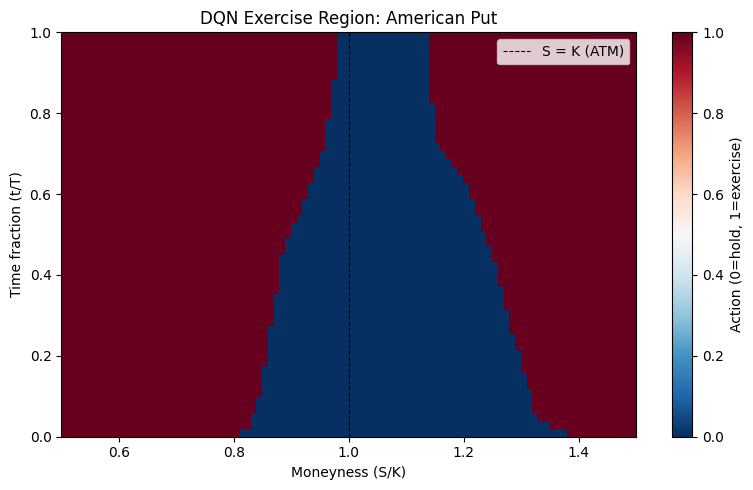

Saved exercise_region.png
Sanity check: exercise (red/1) should cluster at low S/K (deep ITM put), mostly near expiry, forming a boundary rather than being scattered randomly.


In [18]:
# %% Cell 11 — Exercise-region plot (Part B requirement)

def policy_grid(policy_fn, steps=50, money_min=0.5, money_max=1.5, n_money=100):
    grid = []

    for step in range(steps + 1):
        row = []

        time_fraction = step / steps
        time_to_expiry = 1.0 - time_fraction

        for m in np.linspace(money_min, money_max, n_money):
            state = np.array(
                [time_fraction, time_to_expiry, m],
                dtype=np.float32,
            )

            row.append(policy_fn(state))

        grid.append(row)

    return np.array(grid)


grid = policy_grid(
    learned_policy,
    steps=ENV_KWARGS["steps"],
    money_min=0.5,
    money_max=1.5,
    n_money=100,
)

plt.figure(figsize=(8, 5))

plt.imshow(
    grid,
    aspect="auto",
    origin="lower",
    extent=[0.5, 1.5, 0, 1],
    cmap="RdBu_r",
)

plt.colorbar(label="Action (0=hold, 1=exercise)")
plt.xlabel("Moneyness (S/K)")
plt.ylabel("Time fraction (t/T)")
plt.title("DQN Exercise Region: American Put")

plt.axvline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=0.8,
    label="S = K (ATM)",
)

plt.legend()
plt.tight_layout()

plt.savefig("exercise_region.png", dpi=150)

plt.show()

print("Saved exercise_region.png")

print(
    "Sanity check: exercise (red/1) should cluster at low S/K "
    "(deep ITM put), mostly near expiry, forming a boundary "
    "rather than being scattered randomly."
)

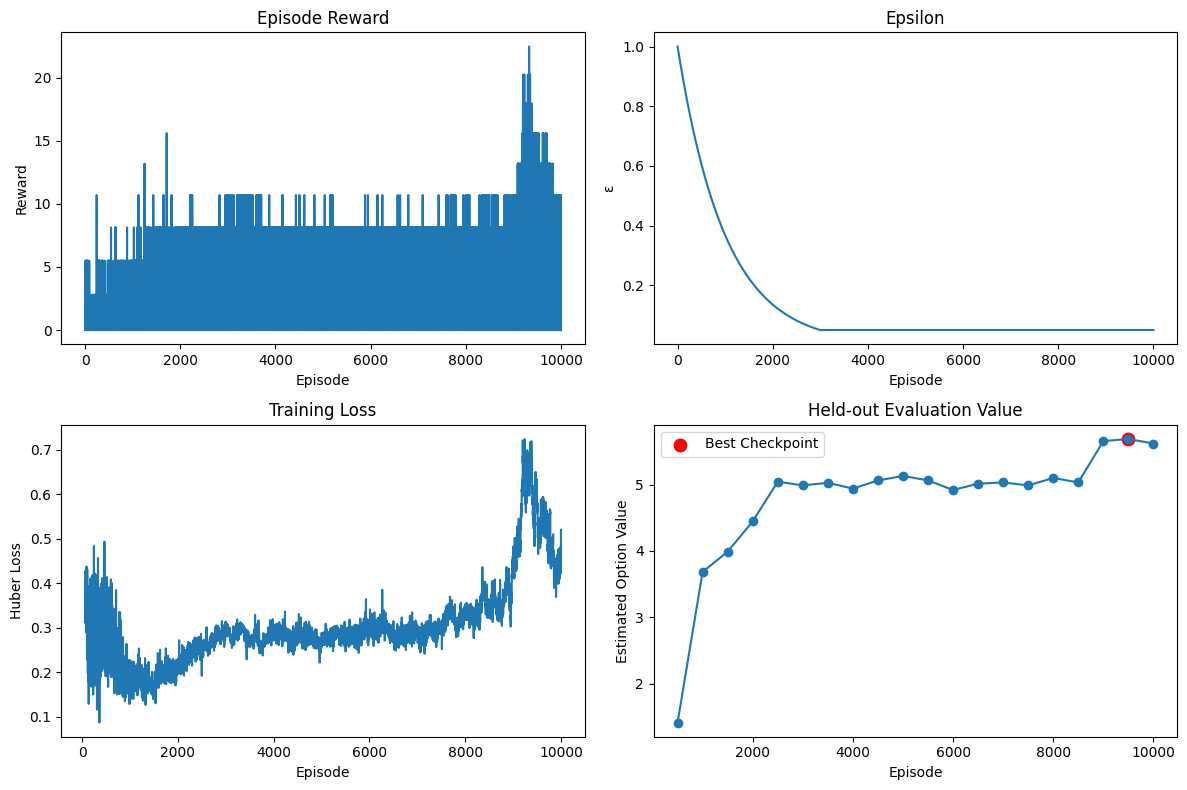

Saved training_diagnostics.png
Saved eval_curve.png
Best held-out value = 5.6892 at episode 9500


In [19]:
# %% Cell 12 — Training diagnostics + held-out evaluation curve

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Episode reward
axes[0, 0].plot(logs["episode_reward"])
axes[0, 0].set_title("Episode Reward")
axes[0, 0].set_xlabel("Episode")
axes[0, 0].set_ylabel("Reward")

# Epsilon
axes[0, 1].plot(logs["epsilon"])
axes[0, 1].set_title("Epsilon")
axes[0, 1].set_xlabel("Episode")
axes[0, 1].set_ylabel("ε")

# Loss
loss = np.asarray(logs["loss"], dtype=float)
axes[1, 0].plot(loss)
axes[1, 0].set_title("Training Loss")
axes[1, 0].set_xlabel("Episode")
axes[1, 0].set_ylabel("Huber Loss")

# Held-out evaluation value
axes[1, 1].plot(
    logs["eval_episode"],
    logs["eval_value"],
    marker="o",
)
axes[1, 1].set_title("Held-out Evaluation Value")
axes[1, 1].set_xlabel("Episode")
axes[1, 1].set_ylabel("Estimated Option Value")

best_idx = np.argmax(logs["eval_value"])

axes[1, 1].scatter(
    logs["eval_episode"][best_idx],
    logs["eval_value"][best_idx],
    s=80,
    color="red",
    label="Best Checkpoint",
)

axes[1, 1].legend()

plt.tight_layout()

plt.savefig("training_diagnostics.png", dpi=150)
plt.savefig("eval_curve.png", dpi=150)

plt.show()

print("Saved training_diagnostics.png")
print("Saved eval_curve.png")

print(
    f"Best held-out value = "
    f"{logs['eval_value'][best_idx]:.4f} "
    f"at episode {logs['eval_episode'][best_idx]}"
)

In [20]:
# %% Cell 13 — Save model + parameters (reproducibility checklist)

online_net.save("week8_dqn_online.keras")
target_net.save("week8_dqn_target.keras")

run_config = {
    "env_kwargs": ENV_KWARGS,
    "episodes": 10_000,
    "batch_size": 128,
    "target_update_every": 250,
    "epsilon_start": 1.0,
    "epsilon_min": 0.05,
    "epsilon_decay": 0.999,
    "lr": 1e-3,
    "seed": SEED,
    "eval_episodes": EVAL_EPISODES,
}

import json

with open("week8_run_config.json", "w") as f:
    json.dump(run_config, f, indent=2)

print("Saved model weights and run_config.json for reproducibility.")

Saved model weights and run_config.json for reproducibility.
